In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import csv 


df = pd.read_csv("employee_data.csv")

np.random.seed(42)
df.loc[df.sample(frac=0.05).index, 'MonthlyIncome'] = np.nan
df.loc[df.sample(frac=0.22).index, 'YearsAtCompany'] = np.nan
df = pd.concat([df, df.iloc[0:15]], ignore_index=True)


print("Dataset successfully loaded locally")
print("Rows and Columns:", df.shape)

Dataset successfully loaded locally
Rows and Columns: (1485, 35)


In [3]:
#task 1

print("DataFrame Shape")
print(df.shape)



print("Column Data Types")
print(df.dtypes)




df.head()

DataFrame Shape
(1485, 35)
Column Data Types
Age                           int64
Attrition                       str
BusinessTravel                  str
DailyRate                     int64
Department                      str
DistanceFromHome              int64
Education                     int64
EducationField                  str
EmployeeCount                 int64
EmployeeNumber                int64
EnvironmentSatisfaction       int64
Gender                          str
HourlyRate                    int64
JobInvolvement                int64
JobLevel                      int64
JobRole                         str
JobSatisfaction               int64
MaritalStatus                   str
MonthlyIncome               float64
MonthlyRate                   int64
NumCompaniesWorked            int64
Over18                          str
OverTime                        str
PercentSalaryHike             int64
PerformanceRating             int64
RelationshipSatisfaction      int64
StandardHours      

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,NaN,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10.0,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0.0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8.0,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,NaN,2,2,2


In [4]:

null_counts = df.isnull().sum()
null_percentages = (null_counts / df.shape[0]) * 100


null_table = pd.DataFrame({
    'Null Count': null_counts, 
    'Percentage (%)': null_percentages
})

print("=== Columns with Missing Values ===")
print(null_table[null_table['Null Count'] > 0])



high_null_cols = null_table[null_table['Percentage (%)'] > 20].index.tolist()
print(f"Columns exceeding 20% null rate: {high_null_cols}")


# Fill numeric columns under 20% nulls with the median (Corrected Standard Assignment)
for col in df.columns:
    if df[col].isnull().sum() > 0 and col not in high_null_cols:
        if pd.api.types.is_numeric_dtype(df[col]):
            median_value = df[col].median()
            df[col] = df[col].fillna(median_value)
            print(f"Imputed missing values in '{col}' with median: {median_value}")

=== Columns with Missing Values ===
                Null Count  Percentage (%)
MonthlyIncome           74        4.983165
YearsAtCompany         327       22.020202
Columns exceeding 20% null rate: ['YearsAtCompany']
Imputed missing values in 'MonthlyIncome' with median: 4876.0


In [5]:

duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows detected: {duplicate_count}")

df = df.drop_duplicates()
print(f"Dataset shape after removing duplicates: {df.shape}")


print(" Updated Null Percentages ")
updated_null_pct = (df.isnull().sum() / df.shape[0]) * 100
print(updated_null_pct[updated_null_pct > 0])

Number of duplicate rows detected: 15
Dataset shape after removing duplicates: (1470, 35)
 Updated Null Percentages 
YearsAtCompany    21.972789
dtype: float64


In [6]:

df['JobSatisfaction'] = df['JobSatisfaction'].astype(str)




mem_before = df.memory_usage(deep=True).sum()
print(f"Memory usage BEFORE: {mem_before / 1024:.2f} KB")


df['JobSatisfaction'] = pd.to_numeric(df['JobSatisfaction'], errors='coerce')


df['Department'] = df['Department'].astype('category')


mem_after = df.memory_usage(deep=True).sum()
print(f"Memory usage AFTER: {mem_after / 1024:.2f} KB")
print(f"Total Memory Saved: {(mem_before - mem_after) / 1024:.2f} KB")

Memory usage BEFORE: 1100.82 KB
Memory usage AFTER: 948.06 KB
Total Memory Saved: 152.76 KB


In [7]:


display(df.describe())


print(" Column Skewness Values ")
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
skew_values = df[numeric_cols].skew()
print(skew_values)



highest_skew_col = skew_values.abs().idxmax()
highest_skew_val = skew_values[highest_skew_col]

print(f"Column with the highest absolute skewness: '{highest_skew_col}'")
print(f"Skewness Value: {highest_skew_val:.4f}")

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1147.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.128160,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.275257,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,10.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,37.000000,18.000000,15.000000,17.000000


 Column Skewness Values 
Age                         0.413286
DailyRate                  -0.003519
DistanceFromHome            0.958118
Education                  -0.289681
EmployeeCount               0.000000
EmployeeNumber              0.016574
EnvironmentSatisfaction    -0.321654
HourlyRate                 -0.032311
JobInvolvement             -0.498419
JobLevel                    1.025401
JobSatisfaction            -0.329672
MonthlyIncome               1.435363
MonthlyRate                 0.018578
NumCompaniesWorked          1.026471
PercentSalaryHike           0.821128
PerformanceRating           1.921883
RelationshipSatisfaction   -0.302828
StandardHours               0.000000
StockOptionLevel            0.968980
TotalWorkingYears           1.117172
TrainingTimesLastYear       0.553124
WorkLifeBalance            -0.552480
YearsAtCompany              1.745224
YearsInCurrentRole          0.917363
YearsSinceLastPromotion     1.984290
YearsWithCurrManager        0.833451
dtype: float6

In [8]:
print("Outlier Count per Column (IQR Method) ")


for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
   
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    
   
    if len(outliers) > 0:
        print(f"Column '{col}': Found {len(outliers)} outliers")

Outlier Count per Column (IQR Method) 
Column 'MonthlyIncome': Found 123 outliers
Column 'NumCompaniesWorked': Found 52 outliers
Column 'PerformanceRating': Found 226 outliers
Column 'StockOptionLevel': Found 85 outliers
Column 'TotalWorkingYears': Found 63 outliers
Column 'TrainingTimesLastYear': Found 238 outliers
Column 'YearsAtCompany': Found 53 outliers
Column 'YearsInCurrentRole': Found 21 outliers
Column 'YearsSinceLastPromotion': Found 107 outliers
Column 'YearsWithCurrManager': Found 14 outliers


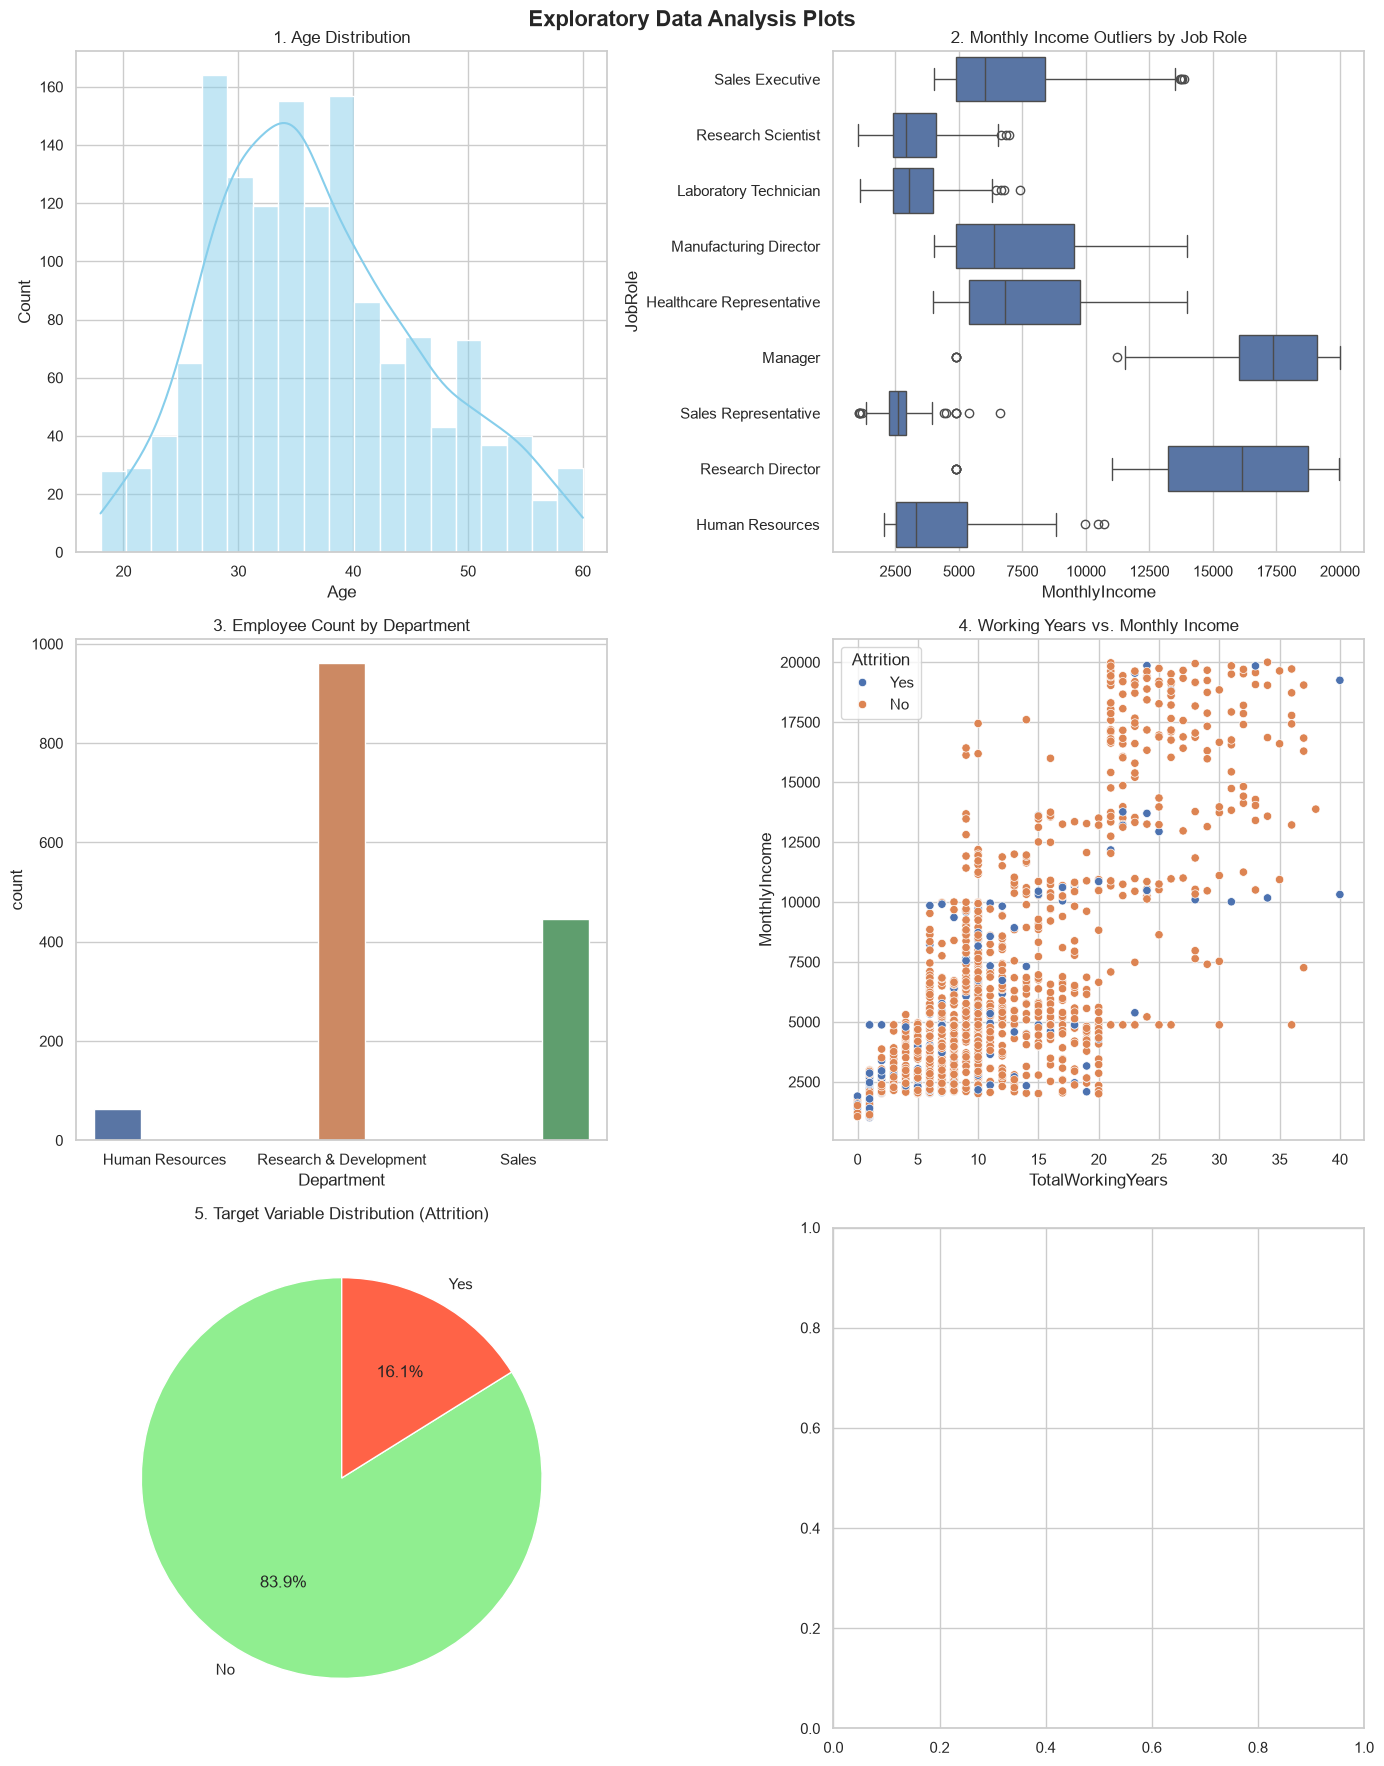

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns


sns.set_theme(style="whitegrid")


fig, axes = plt.subplots(3, 2, figsize=(14, 18))
fig.suptitle('Exploratory Data Analysis Plots', fontsize=16, fontweight='bold')

# Chart 1: Histogram (Age Distribution)
sns.histplot(df['Age'], kde=True, ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title('1. Age Distribution')

# Chart 2: Box Plot (Monthly Income by Job Role)
sns.boxplot(x='MonthlyIncome', y='JobRole', data=df, ax=axes[0, 1])
axes[0, 1].set_title('2. Monthly Income Outliers by Job Role')

# Chart 3: Bar Chart (Department Counts)
sns.countplot(x='Department', data=df, ax=axes[1, 0], hue='Department', legend=False)
axes[1, 0].set_title('3. Employee Count by Department')

# Chart 4: Scatter Plot (Working Years vs Monthly Income)
sns.scatterplot(x='TotalWorkingYears', y='MonthlyIncome', hue='Attrition', data=df, ax=axes[1, 1])
axes[1, 1].set_title('4. Working Years vs. Monthly Income')

# Chart 5: Pie Chart (Target Distribution - Attrition)
attrition_counts = df['Attrition'].value_counts()
axes[2, 0].pie(attrition_counts, labels=attrition_counts.index, autopct='%1.1f%%', colors=['lightgreen', 'tomato'], startangle=90)
axes[2, 0].set_title('5. Target Variable Distribution (Attrition)')



plt.tight_layout()
plt.show()

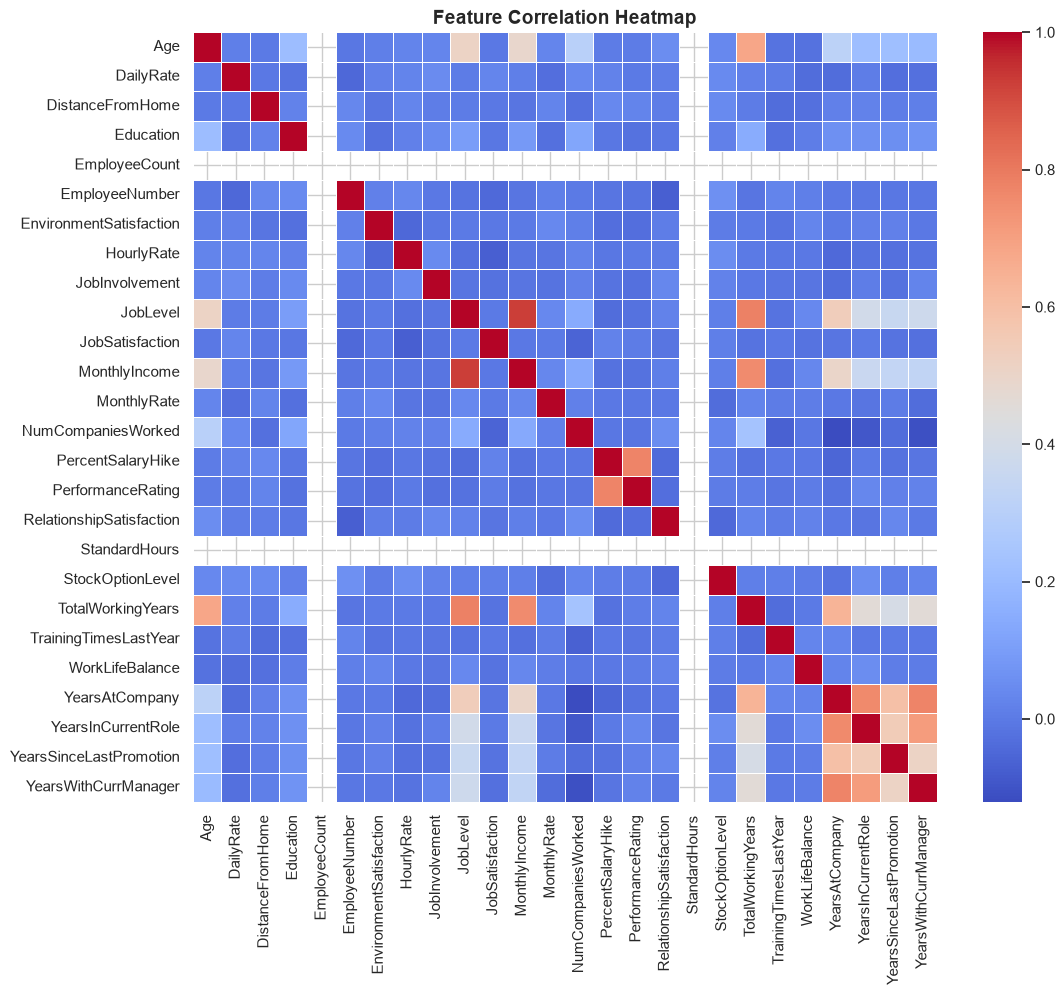

In [10]:

correlation_matrix = df[numeric_cols].corr()

plt.figure(figsize=(12, 10))

sns.heatmap(
    correlation_matrix, 
    annot=False,          
    cmap='coolwarm',      
    fmt=".2f", 
    linewidths=0.5
)

plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.show()

In [11]:

numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
skew_values = df[numeric_cols].skew()


top_2_skewed_cols = skew_values.abs().nlargest(2).index.tolist()

print(" IMPUTATION STRATEGY COMPARISON ")
for col in top_2_skewed_cols:
    col_mean = df[col].mean()
    col_median = df[col].median()
    print(f"\nColumn: '{col}' (Skewness: {skew_values[col]:.4f})")
    print(f"  -> Pre-Imputation Mean:   {col_mean:.2f}")
    print(f"  -> Pre-Imputation Median: {col_median:.2f}")
    
   
    df[col] = df[col].fillna(col_median)
    print(f"  -> Filled nulls with Median.")


print(" Verification: Remaining Null Counts ")
print(df[top_2_skewed_cols].isnull().sum())

 IMPUTATION STRATEGY COMPARISON 

Column: 'YearsSinceLastPromotion' (Skewness: 1.9843)
  -> Pre-Imputation Mean:   2.19
  -> Pre-Imputation Median: 1.00
  -> Filled nulls with Median.

Column: 'PerformanceRating' (Skewness: 1.9219)
  -> Pre-Imputation Mean:   3.15
  -> Pre-Imputation Median: 3.00
  -> Filled nulls with Median.
 Verification: Remaining Null Counts 
YearsSinceLastPromotion    0
PerformanceRating          0
dtype: int64


In [12]:
# 1. Compute Pearson and Spearman correlation matrices
pearson_mat = df[numeric_cols].corr()
spearman_mat = df[numeric_cols].corr(method='spearman')

# 2. Compute the absolute difference matrix
diff_mat = (spearman_mat - pearson_mat).abs()

# 3. Print both full matrices clearly
print("=== PEARSON CORRELATION MATRIX ===")
display(pearson_mat.round(4))
print("\n" + "="*50 + "\n")

print("=== SPEARMAN RANK CORRELATION MATRIX ===")
display(spearman_mat.round(4))
print("\n" + "="*50 + "\n")

# 4. Extract the unique column pairs and find the top 3 largest differences
# We use a set to avoid counting pairs twice (e.g., ColA-ColB and ColB-ColA)
diff_list = []
seen_pairs = set()

for col1 in numeric_cols:
    for col2 in numeric_cols:
        if col1 != col2:
            pair = tuple(sorted([col1, col2]))
            if pair not in seen_pairs:
                seen_pairs.add(pair)
                p_val = pearson_mat.loc[col1, col2]
                s_val = spearman_mat.loc[col1, col2]
                d_val = diff_mat.loc[col1, col2]
                diff_list.append({
                    'Variable 1': col1,
                    'Variable 2': col2,
                    'Pearson': p_val,
                    'Spearman': s_val,
                    '|Spearman - Pearson|': d_val
                })

# Convert to DataFrame and sort to get the top 3
diff_table = pd.DataFrame(diff_list)
top_3_diffs = diff_table.sort_values(by='|Spearman - Pearson|', ascending=False).head(3)

print("=== TOP 3 LARGEST CORRELATION DIFFERENCES ===")
display(top_3_diffs.reset_index(drop=True))

=== PEARSON CORRELATION MATRIX ===


,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
Age,1.0000,0.0107,-0.0017,0.2080,NaN,-0.0101,0.0101,0.0243,0.0298,0.5096,...,0.0535,NaN,0.0375,0.6804,-0.0196,-0.0215,0.3165,0.2129,0.2165,0.2021
DailyRate,0.0107,1.0000,-0.0050,-0.0168,NaN,-0.0510,0.0184,0.0234,0.0461,0.0030,...,0.0078,NaN,0.0421,0.0145,0.0025,-0.0378,-0.0375,0.0099,-0.0332,-0.0264
DistanceFromHome,-0.0017,-0.0050,1.0000,0.0210,NaN,0.0329,-0.0161,0.0311,0.0088,0.0053,...,0.0066,NaN,0.0449,0.0046,-0.0369,-0.0266,0.0159,0.0188,0.0100,0.0144
Education,0.2080,-0.0168,0.0210,1.0000,NaN,0.0421,-0.0271,0.0168,0.0424,0.1016,...,-0.0091,NaN,0.0184,0.1483,-0.0251,0.0098,0.0622,0.0602,0.0543,0.0691
EmployeeCount,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
EmployeeNumber,-0.0101,-0.0510,0.0329,0.0421,NaN,1.0000,0.0176,0.0352,-0.0069,-0.0185,...,-0.0699,NaN,0.0622,-0.0144,0.0236,0.0103,-0.0062,-0.0084,-0.0090,-0.0092
EnvironmentSatisfaction,0.0101,0.0184,-0.0161,-0.0271,NaN,0.0176,1.0000,-0.0499,-0.0083,0.0012,...,0.0077,NaN,0.0034,-0.0027,-0.0194,0.0276,0.0002,0.0180,0.0162,-0.0050
HourlyRate,0.0243,0.0234,0.0311,0.0168,NaN,0.0352,-0.0499,1.0000,0.0429,-0.0279,...,0.0013,NaN,0.0503,-0.0023,-0.0085,-0.0046,-0.0457,-0.0241,-0.0267,-0.0201
JobInvolvement,0.0298,0.0461,0.0088,0.0424,NaN,-0.0069,-0.0083,0.0429,1.0000,-0.0126,...,0.0343,NaN,0.0215,-0.0055,-0.0153,-0.0146,-0.0356,0.0087,-0.0242,0.0260
JobLevel,0.5096,0.0030,0.0053,0.1016,NaN,-0.0185,0.0012,-0.0279,-0.0126,1.0000,...,0.0216,NaN,0.0140,0.7822,-0.0182,0.0378,0.5374,0.3894,0.3539,0.3753




=== SPEARMAN RANK CORRELATION MATRIX ===


,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
Age,1.0000,0.0073,-0.0193,0.2049,NaN,-0.0018,0.0098,0.0289,0.0345,0.4896,...,0.0461,NaN,0.0566,0.6569,0.0003,-0.0037,0.2581,0.1980,0.1736,0.1948
DailyRate,0.0073,1.0000,-0.0028,-0.0136,NaN,-0.0518,0.0190,0.0235,0.0425,0.0038,...,0.0097,NaN,0.0385,0.0210,-0.0113,-0.0404,-0.0259,0.0072,-0.0376,-0.0047
DistanceFromHome,-0.0193,-0.0028,1.0000,0.0157,NaN,0.0389,-0.0104,0.0204,0.0344,0.0221,...,0.0059,NaN,0.0302,-0.0029,-0.0248,-0.0204,0.0283,0.0137,-0.0047,0.0044
Education,0.2049,-0.0136,0.0157,1.0000,NaN,0.0428,-0.0276,0.0144,0.0372,0.1074,...,-0.0132,NaN,0.0138,0.1622,-0.0237,0.0174,0.0562,0.0546,0.0322,0.0513
EmployeeCount,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
EmployeeNumber,-0.0018,-0.0518,0.0389,0.0428,NaN,1.0000,0.0218,0.0347,-0.0025,-0.0111,...,-0.0730,NaN,0.0595,-0.0037,0.0265,0.0100,0.0157,-0.0011,0.0079,-0.0051
EnvironmentSatisfaction,0.0098,0.0190,-0.0104,-0.0276,NaN,0.0218,1.0000,-0.0524,-0.0153,-0.0002,...,0.0054,NaN,0.0098,-0.0139,-0.0117,0.0272,0.0049,0.0201,0.0261,-0.0017
HourlyRate,0.0289,0.0235,0.0204,0.0144,NaN,0.0347,-0.0524,1.0000,0.0439,-0.0339,...,0.0003,NaN,0.0505,-0.0121,0.0003,-0.0100,-0.0444,-0.0340,-0.0524,-0.0138
JobInvolvement,0.0345,0.0425,0.0344,0.0372,NaN,-0.0025,-0.0153,0.0439,1.0000,-0.0184,...,0.0379,NaN,0.0345,0.0064,0.0020,-0.0199,0.0118,0.0155,-0.0083,0.0374
JobLevel,0.4896,0.0038,0.0221,0.1074,NaN,-0.0111,-0.0002,-0.0339,-0.0184,1.0000,...,0.0113,NaN,0.0478,0.7347,-0.0197,0.0405,0.4752,0.3911,0.2691,0.3709




=== TOP 3 LARGEST CORRELATION DIFFERENCES ===


,Variable 1,Variable 2,Pearson,Spearman,|Spearman - Pearson|
0,PercentSalaryHike,PerformanceRating,0.773550,0.628519,0.145031
1,YearsAtCompany,YearsInCurrentRole,0.759774,0.859736,0.099962
2,JobLevel,YearsSinceLastPromotion,0.353885,0.269096,0.084789


In [13]:
# 1. Compute grouped aggregation for Department vs MonthlyIncome
grouped_stats = df.groupby('Department', observed=False)['MonthlyIncome'].agg(['mean', 'std', 'count'])

print("=== SUB-TASK C: GROUPED AGGREGATION ===")
display(grouped_stats)
print("\n" + "="*50 + "\n")

# 2. Dynamically calculate the highest/lowest ratio for your analysis
highest_mean = grouped_stats['mean'].max()
lowest_mean = grouped_stats['mean'].min()
mean_ratio = highest_mean / lowest_mean

print(f"Ratio of Highest Group Mean to Lowest Group Mean: {mean_ratio:.2f}")
print("\n" + "="*50 + "\n")

# 3. Save the clean dataset to the requested CSV file
df.to_csv('cleaned_data.csv', index=False)
print("SUCCESS: 'cleaned_data.csv' has been generated and saved locally!")

=== SUB-TASK C: GROUPED AGGREGATION ===


,mean,std,count
Department,,,
Human Resources,6446.253968,5612.515079,63
Research & Development,6231.112383,4807.539347,961
Sales,6814.569507,3969.174979,446




Ratio of Highest Group Mean to Lowest Group Mean: 1.09


SUCCESS: 'cleaned_data.csv' has been generated and saved locally!
